# Fourier Neural Operator (FNO) for Tropical Cyclone Forecasting

Trains a 2D Fourier Neural Operator on Western Pacific (WP) storm-centred atmospheric grids to predict **direction** (8 classes) and **intensity change** (4 classes). Evaluates zero-shot transfer to the South Pacific (SP) and fine-tunes on a small SP subset.

**Architecture overview** — The FNO (Li et al., ICLR 2021) learns global convolution kernels in Fourier space. Each spectral layer applies `rfft2 → truncated mode multiplication → irfft2`, with a pointwise skip connection. This makes the operator mesh-invariant and resolution-invariant — properties that should benefit cross-basin transfer where the underlying atmospheric physics is shared.

**References:**
- Li et al. (2021) — *Fourier Neural Operator for Parametric PDEs* (ICLR 2021)
- Pathak et al. (2022) — *FourCastNet: A Global Data-driven High-resolution Weather Forecasting Model* (uses AFNO)
- Bonev et al. (2023) — *Spherical Fourier Neural Operators* (ICML 2023)

## Section 0: Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from pathlib import Path
from collections import Counter
from copy import deepcopy
from tqdm.auto import tqdm
import warnings, os

warnings.filterwarnings("ignore")

# ── Paths ──
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

# ── FNO hyperparameters ──
N_MODES         = 12      # truncated Fourier modes per spatial dimension
HIDDEN_CHANNELS = 32      # width of spectral layers (reduced — 3k samples)
N_LAYERS        = 4       # number of spectral convolution blocks
IN_CHANNELS     = 15      # SST + u/v/z at 4 pressure levels + shear + vorticity

# ── Training ──
BATCH_SIZE  = 64
LR          = 5e-4
WEIGHT_DECAY = 1e-3
EPOCHS      = 80
PATIENCE    = 15          # early stopping patience
DIR_WEIGHT  = 0.5         # loss = DIR_WEIGHT * L_dir + (1 - DIR_WEIGHT) * L_int
OPTIMIZER   = "adamw"     # "adamw" or "muon"

# ── Multimodal fusion ──
USE_ENV = True            # fuse 40-dim environmental features
USE_1D  = True            # fuse 4-dim 1D features (lat, lon, wind, pressure)

# ── Fine-tuning ──
FT_LR       = 1e-4
FT_EPOCHS   = 40
FT_PATIENCE = 10

# ── Task ──
N_DIR_CLASSES = 8
N_INT_CLASSES = 4
DIR_LABELS  = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
INTE_LABELS = ["Weakening", "Steady", "Slow-intens.", "Rapid-intens."]

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU'})")
print(f"Data dir: {DATA_DIR}")

Device: cuda (NVIDIA GeForce RTX 5090)
Data dir: /root/climate-change-group-project/data/processed


/root/anaconda3/envs/climate/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1: Data Loading & Dataset

Load the preprocessed `.pt` tensors produced by the shared preprocessing pipeline. Each file is a dict mapping `storm_id → tensor`. The grids are already channel-wise normalised (z-score using WP train statistics). We flatten these into timestep-level samples, filtering out sentinel labels (`-1`) that mark the last timestep of each storm where no future direction/intensity is available.

In [2]:
# ── Load all splits ──
SPLITS = {
    "wp_train":    {"reflected": False},
    "wp_val":      {"reflected": False},
    "sp_test":     {"reflected": True},
    "sp_ft_train": {"reflected": True},
    "sp_ft_val":   {"reflected": True},
}

raw = {}
for split in SPLITS:
    raw[split] = {
        "grids":  torch.load(DATA_DIR / "grids"  / f"{split}_grids.pt",  weights_only=False),
        "env":    torch.load(DATA_DIR / "env"     / f"{split}_env.pt",    weights_only=False),
        "data1d": torch.load(DATA_DIR / "data1d"  / f"{split}_1d.pt",    weights_only=False),
        "labels": torch.load(DATA_DIR / "labels"  / f"{split}_labels.pt", weights_only=False),
    }

print(f"Loaded {len(SPLITS)} splits")
for split in SPLITS:
    n_storms = len(raw[split]["grids"])
    n_ts = sum(v.shape[0] for v in raw[split]["grids"].values())
    print(f"  {split:15s}: {n_storms:3d} storms, {n_ts:5d} timesteps")

Loaded 5 splits
  wp_train       : 105 storms,  3716 timesteps
  wp_val         :  26 storms,   846 timesteps
  sp_test        :  15 storms,   427 timesteps
  sp_ft_train    :  12 storms,   402 timesteps
  sp_ft_val      :   3 storms,    93 timesteps


In [3]:
class CycloneDataset(Dataset):
    """Flattens storm-level dicts into timestep-level samples.

    Filters out sentinel labels (-1).  Grids are already normalised
    (channel-wise z-score) by the preprocessing pipeline.
    1D features are z-scored using training-set statistics passed at init.
    For SP splits, uses hemisphere-reflected direction labels.
    """
    def __init__(self, grids, env, data1d, labels, use_reflected=False,
                 d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = "direction_reflected" if use_reflected else "direction"

        for storm_id in grids:
            g = grids[storm_id]        # (N_t, 15, 81, 81)
            e = env[storm_id]          # (N_t, 40)
            d = data1d[storm_id]       # (N_t, 4)
            d_lbl = labels[storm_id][dir_key]     # (N_t,)
            i_lbl = labels[storm_id]["intensity"]  # (N_t,)

            for t in range(g.shape[0]):
                if d_lbl[t].item() == -1 or i_lbl[t].item() == -1:
                    continue
                self.samples.append((
                    g[t], e[t], d[t],
                    d_lbl[t].long(), i_lbl[t].long(),
                ))

        # Compute or store 1D normalisation stats
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(dim=0)
            self.d1d_std  = all_1d.std(dim=0).clamp(min=1e-6)
        else:
            self.d1d_mean = d1d_mean
            self.d1d_std  = d1d_std

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        grid, env, d1d, dir_lbl, int_lbl = self.samples[idx]
        d1d = (d1d - self.d1d_mean) / self.d1d_std
        return grid, env, d1d, dir_lbl, int_lbl

In [4]:
# ── Build datasets and loaders ──
# Build WP train first to get 1D normalisation stats
datasets = {}
datasets["wp_train"] = CycloneDataset(
    raw["wp_train"]["grids"], raw["wp_train"]["env"],
    raw["wp_train"]["data1d"], raw["wp_train"]["labels"],
    use_reflected=False
)
# Reuse WP train 1D stats for all other splits (prevent leakage)
d1d_mean = datasets["wp_train"].d1d_mean
d1d_std  = datasets["wp_train"].d1d_std
print(f"1D norm stats — mean: {d1d_mean.tolist()}, std: {d1d_std.tolist()}")

for split, cfg in SPLITS.items():
    if split == "wp_train":
        continue
    datasets[split] = CycloneDataset(
        raw[split]["grids"], raw[split]["env"], raw[split]["data1d"],
        raw[split]["labels"], use_reflected=cfg["reflected"],
        d1d_mean=d1d_mean, d1d_std=d1d_std
    )

loaders = {}
for split in SPLITS:
    shuffle = "train" in split
    loaders[split] = DataLoader(
        datasets[split], batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=0, pin_memory=True, drop_last=False
    )

for split, ds in datasets.items():
    print(f"{split:15s}: {len(ds):5d} valid samples")

# Verify a sample
g, e, d, dl, il = datasets["wp_train"][0]
print(f"\nSample shapes — grid: {g.shape}, env: {e.shape}, 1d: {d.shape}, dir: {dl}, int: {il}")
print(f"Grid stats  — mean: {g.mean():.4f}, std: {g.std():.4f}")
print(f"1D (normed) — {d}")

1D norm stats — mean: [0.25115007162094116, -0.30904674530029297, -5.3783392906188965, 2.2481181621551514], std: [0.41245394945144653, 0.4831640124320984, 5.254057884216309, 2.3741278648376465]
wp_train       :  3252 valid samples
wp_val         :   730 valid samples
sp_test        :   367 valid samples
sp_ft_train    :   354 valid samples
sp_ft_val      :    81 valid samples

Sample shapes — grid: torch.Size([15, 81, 81]), env: torch.Size([40]), 1d: torch.Size([4]), dir: 5, int: 0
Grid stats  — mean: -0.0329, std: 0.6397
1D (normed) — tensor([ 1.4277, -1.5956,  0.6696,  0.3925])


In [5]:
# ── Class weights (inverse frequency from WP train) ──
dir_counts = Counter()
int_counts = Counter()
for _, _, _, dl, il in datasets["wp_train"].samples:
    dir_counts[dl.item()] += 1
    int_counts[il.item()] += 1

n_total = len(datasets["wp_train"])

dir_weights = torch.zeros(N_DIR_CLASSES)
for c in range(N_DIR_CLASSES):
    dir_weights[c] = n_total / (N_DIR_CLASSES * max(dir_counts[c], 1))

int_weights = torch.zeros(N_INT_CLASSES)
for c in range(N_INT_CLASSES):
    int_weights[c] = n_total / (N_INT_CLASSES * max(int_counts[c], 1))

print("Direction class distribution (WP train):")
for c in range(N_DIR_CLASSES):
    print(f"  {DIR_LABELS[c]:4s}: {dir_counts[c]:4d} ({dir_counts[c]/n_total*100:5.1f}%)  weight={dir_weights[c]:.2f}")

print(f"\nIntensity class distribution (WP train):")
for c in range(N_INT_CLASSES):
    print(f"  {INTE_LABELS[c]:14s}: {int_counts[c]:4d} ({int_counts[c]/n_total*100:5.1f}%)  weight={int_weights[c]:.2f}")

Direction class distribution (WP train):
  E   :  218 (  6.7%)  weight=1.86
  SE  :   29 (  0.9%)  weight=14.02
  S   :   18 (  0.6%)  weight=22.58
  SW  :   62 (  1.9%)  weight=6.56
  W   :  917 ( 28.2%)  weight=0.44
  NW  :  993 ( 30.5%)  weight=0.41
  N   :  529 ( 16.3%)  weight=0.77
  NE  :  486 ( 14.9%)  weight=0.84

Intensity class distribution (WP train):
  Weakening     : 1491 ( 45.8%)  weight=0.55
  Steady        :  193 (  5.9%)  weight=4.21
  Slow-intens.  : 1124 ( 34.6%)  weight=0.72
  Rapid-intens. :  444 ( 13.7%)  weight=1.83


## Section 2: FNO Architecture

The core idea of the Fourier Neural Operator is to learn convolution kernels directly in the frequency domain. A standard spatial convolution has a limited receptive field, but a Fourier-space multiplication corresponds to a **global** convolution — capturing basin-wide atmospheric patterns in a single layer.

Each **spectral layer** performs:
1. `rfft2`: transform the spatial field to the frequency domain
2. Multiply the lowest `N_MODES` Fourier coefficients by learnable complex weights (higher modes are zeroed out)
3. `irfft2`: transform back to physical space
4. Add a pointwise skip connection (`1×1` conv), apply BatchNorm + GELU, and add a **residual connection** from the block input

Key design choices for this dataset (~3k samples):
- **BatchNorm2d** (not InstanceNorm) — InstanceNorm was found to kill gradients through the spectral layers, preventing training
- **True residual connections** (`x + block(x)`) — stabilises gradient flow across 4 layers
- **Xavier-like spectral weight init** — the original FNO uses uniform `rand` not `randn`; we use `scale = sqrt(2/(Cin+Cout))` for proper gradient magnitudes
- **Reduced capacity** (32 hidden channels, 12 modes) — prevents overfitting given the small dataset size

In [6]:
class SpectralConv2d(nn.Module):
    """2D Fourier spectral convolution layer.

    Performs global convolution via FFT: learns complex-valued weights
    for the lowest (modes1 × modes2) Fourier coefficients.
    Uses uniform init (as in the original Li et al. code) to ensure
    non-trivial initial spectral responses.
    """
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        # Xavier-like scale for complex weights
        scale = (2 / (in_channels + out_channels)) ** 0.5
        self.weights1 = nn.Parameter(
            scale * (torch.rand(in_channels, out_channels, modes1, modes2,
                                dtype=torch.cfloat) - 0.5))
        self.weights2 = nn.Parameter(
            scale * (torch.rand(in_channels, out_channels, modes1, modes2,
                                dtype=torch.cfloat) - 0.5))

    def compl_mul2d(self, x, weights):
        """Complex-valued einsum: (B,Ci,H,W) × (Ci,Co,H,W) → (B,Co,H,W)"""
        return torch.einsum("bixy,ioxy->boxy", x, weights)

    def forward(self, x):
        B = x.shape[0]
        H, W = x.shape[-2], x.shape[-1]

        # Forward FFT (real-valued input → half-complex output)
        x_ft = torch.fft.rfft2(x)  # (B, C, H, W//2+1)

        out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)

        # Multiply the two relevant quadrants of the rfft2 output
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2],
                             self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2],
                             self.weights2)

        # Inverse FFT back to spatial domain
        return torch.fft.irfft2(out_ft, s=(H, W))

In [7]:
class FNO2dClassifier(nn.Module):
    """Fourier Neural Operator for tropical cyclone classification.

    Architecture:
        Lifting (1×1 conv) → N spectral blocks with residual connections
        → Projection (1×1 conv) → Global Average Pooling
        → [optional: concat env + 1D features]
        → MLP direction head (8 classes)
        → MLP intensity head (4 classes)

    Key design choices vs. vanilla FNO:
    - BatchNorm instead of InstanceNorm (preserves gradient flow)
    - True residual connections (x + block(x)) instead of just skip convs
    - Dropout for regularisation (small dataset)
    """
    def __init__(self, in_channels=15, hidden_channels=32, n_modes=12,
                 n_layers=4, n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 dropout=0.1):
        super().__init__()
        self.use_env = use_env
        self.use_1d  = use_1d

        # ── Lifting: project input channels to hidden dimension ──
        self.lifting = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 1),
            nn.GELU(),
        )

        # ── Spectral convolution blocks with residual connections ──
        self.spectral_layers = nn.ModuleList()
        self.skip_convs      = nn.ModuleList()
        self.norms           = nn.ModuleList()
        self.dropouts        = nn.ModuleList()
        for _ in range(n_layers):
            self.spectral_layers.append(
                SpectralConv2d(hidden_channels, hidden_channels, n_modes, n_modes))
            self.skip_convs.append(
                nn.Conv2d(hidden_channels, hidden_channels, 1))
            self.norms.append(nn.BatchNorm2d(hidden_channels))
            self.dropouts.append(nn.Dropout2d(dropout))

        # ── Projection ──
        self.projection = nn.Sequential(
            nn.Conv2d(hidden_channels, hidden_channels, 1),
            nn.GELU(),
        )

        # ── Classification heads ──
        aux_dim = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        head_in = hidden_channels + aux_dim

        self.head_dir = nn.Sequential(
            nn.Linear(head_in, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(64, n_dir_classes)
        )
        self.head_int = nn.Sequential(
            nn.Linear(head_in, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(64, n_int_classes)
        )

    def forward(self, grid, env=None, d1d=None):
        # grid: (B, 15, 81, 81)
        x = self.lifting(grid)  # (B, H, 81, 81)

        for spec, skip, norm, drop in zip(
                self.spectral_layers, self.skip_convs,
                self.norms, self.dropouts):
            # Residual: x + GELU(BN(spectral(x) + skip(x)))
            residual = x
            x = norm(spec(x) + skip(x))
            x = drop(F.gelu(x))
            x = x + residual

        x = self.projection(x)          # (B, H, 81, 81)
        x = x.mean(dim=(-2, -1))        # Global average pooling → (B, H)

        # Late fusion of auxiliary features
        parts = [x]
        if self.use_env and env is not None:
            parts.append(env)
        if self.use_1d and d1d is not None:
            parts.append(d1d)
        x = torch.cat(parts, dim=-1)

        return self.head_dir(x), self.head_int(x)

In [8]:
# ── Instantiate and inspect ──
model = FNO2dClassifier(
    in_channels=IN_CHANNELS, hidden_channels=HIDDEN_CHANNELS,
    n_modes=N_MODES, n_layers=N_LAYERS,
    n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
    env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_train:,}")
print(f"Samples/params ratio: {len(datasets['wp_train'])/n_params:.2f}")

# Smoke test
with torch.no_grad():
    dummy_g = torch.randn(2, 15, 81, 81, device=DEVICE)
    dummy_e = torch.randn(2, 40, device=DEVICE)
    dummy_d = torch.randn(2, 4,  device=DEVICE)
    d_out, i_out = model(dummy_g, dummy_e, dummy_d)
    print(f"Direction logits: {d_out.shape}  Intensity logits: {i_out.shape}")
    print(f"Logit range: [{d_out.min():.3f}, {d_out.max():.3f}] (should NOT be ~0)")

Total parameters:     1,222,700
Trainable parameters: 1,222,700
Samples/params ratio: 0.00
Direction logits: torch.Size([2, 8])  Intensity logits: torch.Size([2, 4])
Logit range: [-0.111, 0.217] (should NOT be ~0)


## Section 2b: Hyperparameter Optimisation (Optuna)

We use [Optuna](https://optuna.org/) to search over **architecture**, **optimiser**, **scheduler**, **augmentation**, and **regularisation** jointly. Each trial trains the FNO for up to 30 epochs with early stopping on validation direction accuracy.

The search space includes:
- **Architecture**: hidden channels (32–96), Fourier modes (8–24), layers (2–6), head width
- **Optimiser**: AdamW vs Muon, learning rate, weight decay
- **Scheduler**: CosineAnnealing vs OneCycleLR
- **Augmentation**: random horizontal/vertical flip of grids (physics-preserving for storm-centred fields)
- **Regularisation**: dropout, label smoothing, loss weighting

In [9]:
import optuna, gc
from optuna.trial import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Fixed references for the objective ──
_loader_train = loaders["wp_train"]
_loader_val   = loaders["wp_val"]
_dir_weights  = dir_weights.to(DEVICE)
_int_weights  = int_weights.to(DEVICE)

OPTUNA_EPOCHS   = 30   # max epochs per trial
OPTUNA_PATIENCE = 8    # early stopping within trial
N_TRIALS        = 60   # total trials — ~30 min on RTX 5090


def _cleanup_gpu():
    """Aggressively free GPU memory between trials."""
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


def objective(trial):
    # ── Architecture ──
    hid    = trial.suggest_int("hidden_channels", 32, 96, step=16)
    modes  = trial.suggest_int("n_modes", 8, 24, step=4)
    layers = trial.suggest_int("n_layers", 2, 6)
    head   = trial.suggest_int("head_dim", 64, 256, step=64)

    # ── Regularisation ──
    dropout        = trial.suggest_float("dropout", 0.0, 0.3, step=0.05)
    label_smooth   = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.05)
    dir_weight     = trial.suggest_float("dir_weight", 0.3, 0.7, step=0.1)

    # ── Augmentation ──
    aug_hflip = trial.suggest_categorical("aug_hflip", [True, False])
    aug_vflip = trial.suggest_categorical("aug_vflip", [True, False])

    # ── Optimiser ──
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-4, 5e-3, log=True)
    optim_name = trial.suggest_categorical("optimizer", ["adamw", "muon"])

    # ── Scheduler ──
    sched_name = trial.suggest_categorical("scheduler", ["cosine", "onecycle"])

    # ── Build model on CPU first, then move to GPU ──
    torch.manual_seed(SEED)
    m = FNO2dClassifier(
        in_channels=IN_CHANNELS, hidden_channels=hid, n_modes=modes,
        n_layers=layers, n_dir_classes=N_DIR_CLASSES,
        n_int_classes=N_INT_CLASSES, env_dim=40, d1d_dim=4,
        use_env=True, use_1d=True, dropout=dropout,
    )  # stays on CPU
    # Override head dimensions (still on CPU)
    aux_dim = 40 + 4
    head_in = hid + aux_dim
    m.head_dir = nn.Sequential(
        nn.Linear(head_in, head), nn.GELU(), nn.Dropout(dropout * 2),
        nn.Linear(head, head // 2), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(head // 2, N_DIR_CLASSES),
    )
    m.head_int = nn.Sequential(
        nn.Linear(head_in, head), nn.GELU(), nn.Dropout(dropout * 2),
        nn.Linear(head, head // 2), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(head // 2, N_INT_CLASSES),
    )

    # Move to GPU — catch OOM here
    try:
        m = m.to(DEVICE)
    except torch.cuda.OutOfMemoryError:
        del m
        _cleanup_gpu()
        raise optuna.TrialPruned()

    # ── Optimiser setup ──
    if optim_name == "muon":
        try:
            from torch.optim import Muon
            muon_params, adam_params = [], []
            for name, p in m.named_parameters():
                if not p.requires_grad:
                    continue
                if p.ndim >= 2 and "lifting" not in name and "head" not in name:
                    muon_params.append(p)
                else:
                    adam_params.append(p)
            opt = Muon(muon_params, lr=lr, momentum=0.95, nesterov=True,
                       alternate_optimizer=torch.optim.AdamW(
                           adam_params, lr=lr, weight_decay=wd))
        except Exception:
            opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    else:
        opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)

    # ── Scheduler setup ──
    if sched_name == "onecycle":
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=lr * 3, epochs=OPTUNA_EPOCHS,
            steps_per_epoch=len(_loader_train))
        step_per_batch = True
    else:
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=OPTUNA_EPOCHS, eta_min=1e-6)
        step_per_batch = False

    # ── Loss ──
    loss_d = nn.CrossEntropyLoss(weight=_dir_weights,
                                  label_smoothing=label_smooth)
    loss_i = nn.CrossEntropyLoss(weight=_int_weights,
                                  label_smoothing=label_smooth)

    # ── Training loop ──
    best_val_acc = 0.0
    patience_ctr = 0

    try:
        for epoch in range(1, OPTUNA_EPOCHS + 1):
            m.train()
            for grid, env, d1d, dl, il in _loader_train:
                grid, env, d1d = grid.to(DEVICE), env.to(DEVICE), d1d.to(DEVICE)
                dl, il = dl.to(DEVICE), il.to(DEVICE)

                if aug_hflip and torch.rand(1).item() > 0.5:
                    grid = grid.flip(-1)
                if aug_vflip and torch.rand(1).item() > 0.5:
                    grid = grid.flip(-2)

                d_out, i_out = m(grid, env, d1d)
                loss = dir_weight * loss_d(d_out, dl) + \
                       (1 - dir_weight) * loss_i(i_out, il)

                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                opt.step()
                if step_per_batch:
                    sched.step()

            if not step_per_batch:
                sched.step()

            # ── Validation ──
            m.eval()
            preds, trues = [], []
            with torch.no_grad():
                for grid, env, d1d, dl, il in _loader_val:
                    grid, env, d1d = grid.to(DEVICE), env.to(DEVICE), d1d.to(DEVICE)
                    preds.extend(m(grid, env, d1d)[0].argmax(1).cpu().tolist())
                    trues.extend(dl.tolist())
            val_acc = accuracy_score(trues, preds)

            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_ctr = 0
            else:
                patience_ctr += 1
                if patience_ctr >= OPTUNA_PATIENCE:
                    break
    except torch.cuda.OutOfMemoryError:
        raise optuna.TrialPruned()
    finally:
        # Move model to CPU before deleting to ensure GPU mem is freed
        try:
            m.cpu()
        except Exception:
            pass
        del m, opt
        _cleanup_gpu()

    return best_val_acc


# ── Run the study ──
_cleanup_gpu()  # start clean
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    study_name="fno_hpo",
)
study.optimize(objective, n_trials=N_TRIALS, catch=(Exception,),
               show_progress_bar=True)

print(f"\n{'='*60}")
print(f" Optuna search complete — {len(study.trials)} trials")
print(f"{'='*60}")
completed = [t for t in study.trials if t.state == TrialState.COMPLETE]
print(f" Completed: {len(completed)}, Pruned: {len(study.trials) - len(completed)}")
print(f" Best val direction accuracy: {study.best_value:.4f}")
print(f" Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"   {k:25s}: {v}")


Best trial: 55. Best value: 0.638356: 100%|██████████| 60/60 [47:53<00:00, 47.89s/it]


 Optuna search complete — 60 trials
 Completed: 47, Pruned: 13
 Best val direction accuracy: 0.6384
 Best hyperparameters:
   hidden_channels          : 80
   n_modes                  : 20
   n_layers                 : 2
   head_dim                 : 64
   dropout                  : 0.05
   label_smoothing          : 0.0
   dir_weight               : 0.7
   aug_hflip                : False
   aug_vflip                : False
   lr                       : 0.0007831506014327231
   weight_decay             : 0.003614804534116187
   optimizer                : muon
   scheduler                : cosine


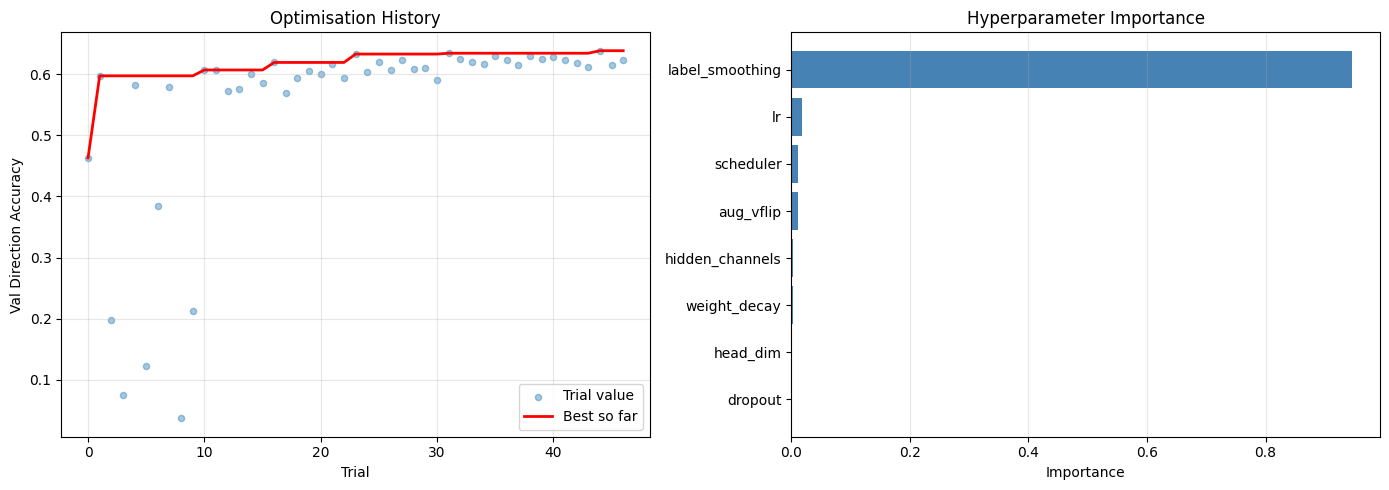


Top 5 trials:
  Trial  55 │ acc=0.6384 │ hid=80 modes=20 layers=2 lr=0.0008 opt=muon sched=cosine
  Trial  39 │ acc=0.6342 │ hid=80 modes=20 layers=2 lr=0.0022 opt=muon sched=cosine
  Trial  28 │ acc=0.6329 │ hid=64 modes=8 layers=5 lr=0.0024 opt=adamw sched=cosine
  Trial  44 │ acc=0.6301 │ hid=80 modes=24 layers=2 lr=0.0025 opt=muon sched=cosine
  Trial  48 │ acc=0.6301 │ hid=80 modes=20 layers=2 lr=0.0016 opt=muon sched=cosine


In [10]:
# ── Optuna results visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Optimization history
completed = [t for t in study.trials if t.state == TrialState.COMPLETE]
vals = [t.value for t in completed]
best_so_far = [max(vals[:i+1]) for i in range(len(vals))]
axes[0].scatter(range(len(vals)), vals, alpha=0.4, s=20, label="Trial value")
axes[0].plot(best_so_far, color="red", linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val Direction Accuracy")
axes[0].set_title("Optimisation History"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2. Hyperparameter importance (top 8)
importances = optuna.importance.get_param_importances(study)
top_params = list(importances.keys())[:8]
top_vals = [importances[k] for k in top_params]
axes[1].barh(top_params[::-1], top_vals[::-1], color="steelblue")
axes[1].set_xlabel("Importance"); axes[1].set_title("Hyperparameter Importance")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fno_optuna_results.png", dpi=150,
            bbox_inches="tight")
plt.show()

# ── Top 5 trials ──
print("\nTop 5 trials:")
top5 = sorted(completed, key=lambda t: t.value, reverse=True)[:5]
for t in top5:
    p = t.params
    print(f"  Trial {t.number:3d} │ acc={t.value:.4f} │ "
          f"hid={p['hidden_channels']} modes={p['n_modes']} "
          f"layers={p['n_layers']} lr={p['lr']:.4f} "
          f"opt={p['optimizer']} sched={p['scheduler']}")

In [11]:
# ── Apply best hyperparameters ──
bp = study.best_params

N_MODES         = bp["n_modes"]
HIDDEN_CHANNELS = bp["hidden_channels"]
N_LAYERS        = bp["n_layers"]
LR              = bp["lr"]
WEIGHT_DECAY    = bp["weight_decay"]
DIR_WEIGHT      = bp["dir_weight"]
OPTIMIZER       = bp["optimizer"]
BEST_DROPOUT    = bp["dropout"]
BEST_LABEL_SMOOTH = bp["label_smoothing"]
BEST_HEAD_DIM   = bp["head_dim"]
BEST_SCHEDULER  = bp["scheduler"]
BEST_AUG_HFLIP  = bp["aug_hflip"]
BEST_AUG_VFLIP  = bp["aug_vflip"]

print("Best hyperparameters applied:")
print(f"  Architecture : hid={HIDDEN_CHANNELS}, modes={N_MODES}, "
      f"layers={N_LAYERS}, head={BEST_HEAD_DIM}")
print(f"  Optimiser    : {OPTIMIZER}, lr={LR:.5f}, wd={WEIGHT_DECAY:.5f}")
print(f"  Scheduler    : {BEST_SCHEDULER}")
print(f"  Regularisation: dropout={BEST_DROPOUT}, "
      f"label_smooth={BEST_LABEL_SMOOTH}, dir_weight={DIR_WEIGHT}")
print(f"  Augmentation : hflip={BEST_AUG_HFLIP}, vflip={BEST_AUG_VFLIP}")

# ── Rebuild model with best params ──
torch.manual_seed(SEED)
model = FNO2dClassifier(
    in_channels=IN_CHANNELS, hidden_channels=HIDDEN_CHANNELS,
    n_modes=N_MODES, n_layers=N_LAYERS,
    n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
    env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
    dropout=BEST_DROPOUT,
).to(DEVICE)

# Replace heads with tuned dimensions
aux_dim = 40 + 4
head_in = HIDDEN_CHANNELS + aux_dim
model.head_dir = nn.Sequential(
    nn.Linear(head_in, BEST_HEAD_DIM), nn.GELU(),
    nn.Dropout(BEST_DROPOUT * 2),
    nn.Linear(BEST_HEAD_DIM, BEST_HEAD_DIM // 2), nn.GELU(),
    nn.Dropout(BEST_DROPOUT),
    nn.Linear(BEST_HEAD_DIM // 2, N_DIR_CLASSES),
).to(DEVICE)
model.head_int = nn.Sequential(
    nn.Linear(head_in, BEST_HEAD_DIM), nn.GELU(),
    nn.Dropout(BEST_DROPOUT * 2),
    nn.Linear(BEST_HEAD_DIM, BEST_HEAD_DIM // 2), nn.GELU(),
    nn.Dropout(BEST_DROPOUT),
    nn.Linear(BEST_HEAD_DIM // 2, N_INT_CLASSES),
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")
print(f"Best Optuna val accuracy: {study.best_value:.4f}")

Best hyperparameters applied:
  Architecture : hid=80, modes=20, layers=2, head=64
  Optimiser    : muon, lr=0.00078, wd=0.00361
  Scheduler    : cosine
  Regularisation: dropout=0.05, label_smooth=0.0, dir_weight=0.7
  Augmentation : hflip=False, vflip=False

Model parameters: 10,281,596
Best Optuna val accuracy: 0.6384


## Section 3: Training on WP (with Optuna-tuned hyperparameters)

We train with a combined loss: `L = DIR_WEIGHT × CrossEntropy(direction) + (1 − DIR_WEIGHT) × CrossEntropy(intensity)`, using inverse-frequency class weights and label smoothing. All hyperparameters below were selected by the Optuna search in Section 2b.

In [12]:
# ── Loss functions (with label smoothing from Optuna) ──
loss_dir_fn = nn.CrossEntropyLoss(weight=dir_weights.to(DEVICE),
                                   label_smoothing=BEST_LABEL_SMOOTH)
loss_int_fn = nn.CrossEntropyLoss(weight=int_weights.to(DEVICE),
                                   label_smoothing=BEST_LABEL_SMOOTH)

# ── Optimizer ──
if OPTIMIZER == "muon":
    try:
        from torch.optim import Muon
        muon_params, adam_params = [], []
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if p.ndim >= 2 and "lifting" not in name and "head" not in name:
                muon_params.append(p)
            else:
                adam_params.append(p)
        optimizer = Muon(
            muon_params, lr=LR, momentum=0.95, nesterov=True,
            alternate_optimizer=torch.optim.AdamW(
                adam_params, lr=LR, weight_decay=WEIGHT_DECAY))
        print(f"Optimizer: Muon ({len(muon_params)} spectral groups) "
              f"+ AdamW ({len(adam_params)} other groups)")
    except Exception as e:
        print(f"Muon not available ({e}), falling back to AdamW")
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                                      weight_decay=WEIGHT_DECAY)
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                                  weight_decay=WEIGHT_DECAY)
    print(f"Optimizer: AdamW (lr={LR:.5f}, wd={WEIGHT_DECAY:.5f})")

# ── Scheduler ──
if BEST_SCHEDULER == "onecycle":
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR * 3, epochs=EPOCHS,
        steps_per_epoch=len(loaders["wp_train"]))
    STEP_PER_BATCH = True
    print(f"Scheduler: OneCycleLR (max_lr={LR*3:.5f})")
else:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)
    STEP_PER_BATCH = False
    print(f"Scheduler: CosineAnnealing (T_max={EPOCHS})")

Muon not available (Muon.__init__() got an unexpected keyword argument 'alternate_optimizer'), falling back to AdamW
Scheduler: CosineAnnealing (T_max=80)


In [13]:
def train_one_epoch(model, loader, optimizer, device, scheduler=None,
                    step_per_batch=False, aug_hflip=False, aug_vflip=False):
    model.train()
    total_loss = 0.0
    correct_dir = correct_int = total = 0

    for grid, env, d1d, dir_lbl, int_lbl in loader:
        grid    = grid.to(device)
        env     = env.to(device)
        d1d     = d1d.to(device)
        dir_lbl = dir_lbl.to(device)
        int_lbl = int_lbl.to(device)

        # ── Data augmentation (random flips) ──
        if aug_hflip and torch.rand(1).item() > 0.5:
            grid = grid.flip(-1)   # horizontal flip
        if aug_vflip and torch.rand(1).item() > 0.5:
            grid = grid.flip(-2)   # vertical flip

        dir_logits, int_logits = model(grid, env, d1d)
        l_dir = loss_dir_fn(dir_logits, dir_lbl)
        l_int = loss_int_fn(int_logits, int_lbl)
        loss  = DIR_WEIGHT * l_dir + (1 - DIR_WEIGHT) * l_int

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if step_per_batch and scheduler is not None:
            scheduler.step()

        bs = grid.size(0)
        total_loss  += loss.item() * bs
        correct_dir += (dir_logits.argmax(1) == dir_lbl).sum().item()
        correct_int += (int_logits.argmax(1) == int_lbl).sum().item()
        total       += bs

    return total_loss / total, correct_dir / total, correct_int / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_dir_pred, all_dir_true = [], []
    all_int_pred, all_int_true = [], []
    total = 0

    for grid, env, d1d, dir_lbl, int_lbl in loader:
        grid    = grid.to(device)
        env     = env.to(device)
        d1d     = d1d.to(device)
        dir_lbl = dir_lbl.to(device)
        int_lbl = int_lbl.to(device)

        dir_logits, int_logits = model(grid, env, d1d)
        l_dir = loss_dir_fn(dir_logits, dir_lbl)
        l_int = loss_int_fn(int_logits, int_lbl)
        loss  = DIR_WEIGHT * l_dir + (1 - DIR_WEIGHT) * l_int

        bs = grid.size(0)
        total_loss += loss.item() * bs
        total      += bs

        all_dir_pred.extend(dir_logits.argmax(1).cpu().tolist())
        all_dir_true.extend(dir_lbl.cpu().tolist())
        all_int_pred.extend(int_logits.argmax(1).cpu().tolist())
        all_int_true.extend(int_lbl.cpu().tolist())

    metrics = {
        "loss":    total_loss / total,
        "dir_acc": accuracy_score(all_dir_true, all_dir_pred),
        "int_acc": accuracy_score(all_int_true, all_int_pred),
        "dir_f1":  f1_score(all_dir_true, all_dir_pred, average="macro",
                            zero_division=0),
        "int_f1":  f1_score(all_int_true, all_int_pred, average="macro",
                            zero_division=0),
        "dir_pred": all_dir_pred, "dir_true": all_dir_true,
        "int_pred": all_int_pred, "int_true": all_int_true,
    }
    return metrics

In [14]:
# ── Training loop with early stopping ──
history = {"train_loss": [], "val_loss": [],
           "train_dir_acc": [], "val_dir_acc": [],
           "train_int_acc": [], "val_int_acc": []}

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_dir_acc, train_int_acc = train_one_epoch(
        model, loaders["wp_train"], optimizer, DEVICE,
        scheduler=scheduler if STEP_PER_BATCH else None,
        step_per_batch=STEP_PER_BATCH,
        aug_hflip=BEST_AUG_HFLIP, aug_vflip=BEST_AUG_VFLIP)

    val_metrics = evaluate(model, loaders["wp_val"], DEVICE)

    if not STEP_PER_BATCH:
        scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_dir_acc"].append(train_dir_acc)
    history["val_dir_acc"].append(val_metrics["dir_acc"])
    history["train_int_acc"].append(train_int_acc)
    history["val_int_acc"].append(val_metrics["int_acc"])

    # Early stopping
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
        marker = " ★"
    else:
        patience_counter += 1
        marker = ""

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"Epoch {epoch:3d}/{EPOCHS} │ "
              f"Train loss={train_loss:.4f} dir={train_dir_acc:.3f} int={train_int_acc:.3f} │ "
              f"Val loss={val_metrics['loss']:.4f} dir={val_metrics['dir_acc']:.3f} "
              f"int={val_metrics['int_acc']:.3f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (patience={PATIENCE})")
        break

# Restore best model
model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")
print(f"Best val dir acc: {max(history['val_dir_acc']):.4f}")

Epoch   1/80 │ Train loss=1.7540 dir=0.190 int=0.231 │ Val loss=1.6898 dir=0.392 int=0.530 ★
Epoch   2/80 │ Train loss=1.3940 dir=0.494 int=0.525 │ Val loss=1.5276 dir=0.519 int=0.499 ★
Epoch   3/80 │ Train loss=1.1684 dir=0.549 int=0.519 │ Val loss=1.3452 dir=0.503 int=0.558 ★
Epoch   5/80 │ Train loss=0.9778 dir=0.611 int=0.591 │ Val loss=1.3597 dir=0.564 int=0.582
Epoch  10/80 │ Train loss=0.6557 dir=0.724 int=0.635 │ Val loss=1.8323 dir=0.605 int=0.582
Epoch  15/80 │ Train loss=0.4746 dir=0.807 int=0.680 │ Val loss=2.2520 dir=0.568 int=0.586

Early stopping at epoch 18 (patience=15)

Best val loss: 1.3452
Best val dir acc: 0.6082


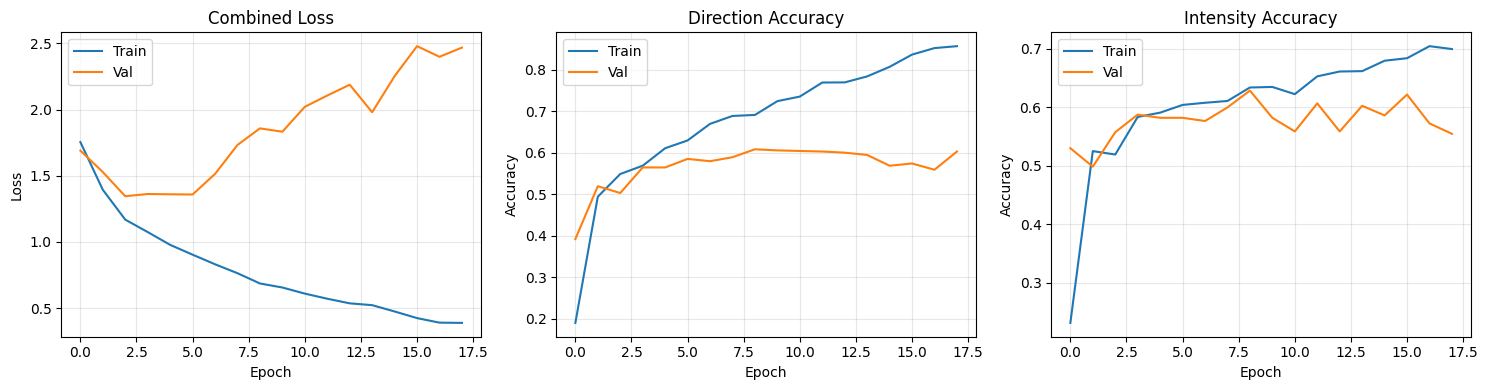

In [15]:
# ── Learning curves ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Combined Loss"); axes[0].legend()

axes[1].plot(history["train_dir_acc"], label="Train")
axes[1].plot(history["val_dir_acc"],   label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Direction Accuracy"); axes[1].legend()

axes[2].plot(history["train_int_acc"], label="Train")
axes[2].plot(history["val_int_acc"],   label="Val")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
axes[2].set_title("Intensity Accuracy"); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fno_learning_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Section 4: WP In-Basin Evaluation

In [16]:
def plot_confusion_matrices(metrics, title_prefix, labels_dir=DIR_LABELS,
                            labels_int=INTE_LABELS):
    """Plot direction and intensity confusion matrices side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_dir = confusion_matrix(metrics["dir_true"], metrics["dir_pred"],
                              labels=list(range(len(labels_dir))))
    cm_int = confusion_matrix(metrics["int_true"], metrics["int_pred"],
                              labels=list(range(len(labels_int))))
    
    sns.heatmap(cm_dir, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_dir, yticklabels=labels_dir, ax=axes[0])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_title(f"{title_prefix} — Direction")
    
    sns.heatmap(cm_int, annot=True, fmt="d", cmap="Oranges",
                xticklabels=labels_int, yticklabels=labels_int, ax=axes[1])
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].set_title(f"{title_prefix} — Intensity")
    
    plt.tight_layout()
    return fig


def print_metrics(metrics, split_name):
    """Print accuracy and F1 summary."""
    print(f"\n{'='*50}")
    print(f" {split_name}")
    print(f"{'='*50}")
    print(f"  Direction — Acc: {metrics['dir_acc']:.3f}  "
          f"F1 (macro): {metrics['dir_f1']:.3f}")
    print(f"  Intensity — Acc: {metrics['int_acc']:.3f}  "
          f"F1 (macro): {metrics['int_f1']:.3f}")

In [17]:
# ── Evaluate on WP validation ──
wp_val_metrics = evaluate(model, loaders["wp_val"], DEVICE)
print_metrics(wp_val_metrics, "WP Validation (in-basin)")

print("\nDirection classification report:")
print(classification_report(wp_val_metrics["dir_true"],
                            wp_val_metrics["dir_pred"],
                            target_names=DIR_LABELS, zero_division=0))

print("Intensity classification report:")
print(classification_report(wp_val_metrics["int_true"],
                            wp_val_metrics["int_pred"],
                            target_names=INTE_LABELS, zero_division=0))


 WP Validation (in-basin)
  Direction — Acc: 0.503  F1 (macro): 0.364
  Intensity — Acc: 0.558  F1 (macro): 0.410

Direction classification report:
              precision    recall  f1-score   support

           E       0.31      0.22      0.26        23
          SE       0.00      0.00      0.00         7
           S       0.05      0.07      0.05        15
          SW       0.26      0.55      0.35        42
           W       0.56      0.58      0.57       209
          NW       0.62      0.49      0.55       205
           N       0.61      0.57      0.59       127
          NE       0.75      0.41      0.53       102

    accuracy                           0.50       730
   macro avg       0.40      0.36      0.36       730
weighted avg       0.57      0.50      0.53       730

Intensity classification report:
               precision    recall  f1-score   support

    Weakening       0.70      0.78      0.74       346
       Steady       0.06      0.17      0.09        40
 

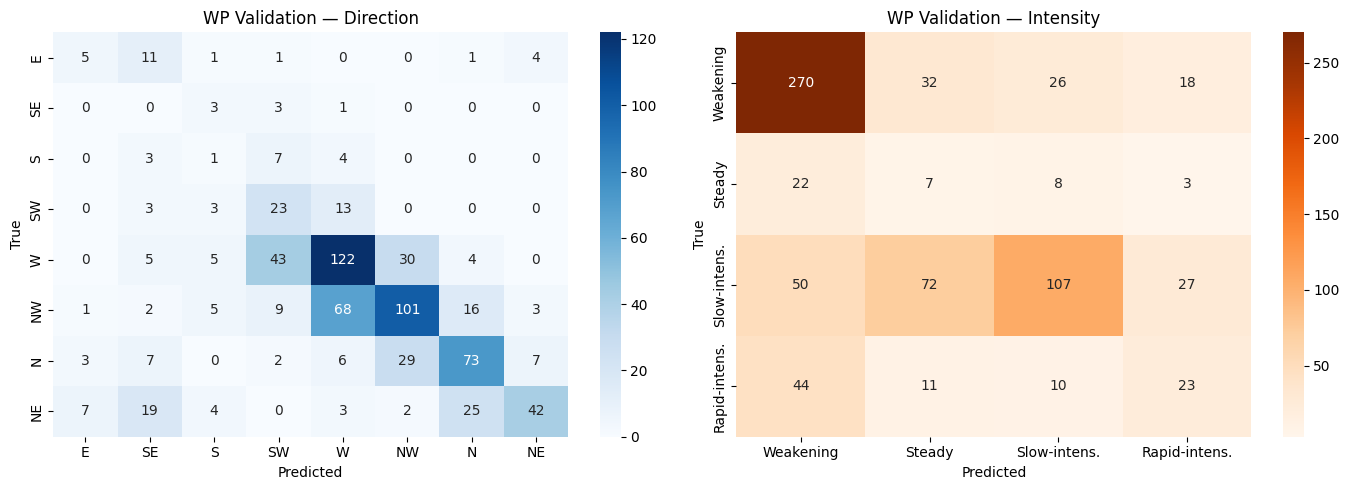

In [18]:
fig = plot_confusion_matrices(wp_val_metrics, "WP Validation")
fig.savefig(PROJECT_ROOT / "figures" / "fno_wp_val_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Section 5: Zero-Shot Transfer to South Pacific

The model trained on WP is evaluated directly on SP without any adaptation. SP labels use `direction_reflected` to account for the Coriolis hemisphere mirror — e.g., a WP storm heading NW (class 5) corresponds to a reflected SP storm heading SW (class 3). This mapping was applied during preprocessing.

In [19]:
# ── Zero-shot evaluation on SP test ──
sp_zs_metrics = evaluate(model, loaders["sp_test"], DEVICE)
print_metrics(sp_zs_metrics, "SP Test (zero-shot transfer)")

print("\nDirection classification report:")
print(classification_report(sp_zs_metrics["dir_true"],
                            sp_zs_metrics["dir_pred"],
                            target_names=DIR_LABELS, zero_division=0))

print("Intensity classification report:")
print(classification_report(sp_zs_metrics["int_true"],
                            sp_zs_metrics["int_pred"],
                            target_names=INTE_LABELS, zero_division=0))


 SP Test (zero-shot transfer)
  Direction — Acc: 0.248  F1 (macro): 0.217
  Intensity — Acc: 0.357  F1 (macro): 0.300

Direction classification report:
              precision    recall  f1-score   support

           E       0.25      0.16      0.20        56
          SE       0.01      0.50      0.02         2
           S       0.12      0.57      0.20         7
          SW       0.08      0.33      0.13        12
           W       0.18      0.02      0.04        91
          NW       0.47      0.25      0.33        59
           N       0.47      0.55      0.51        69
          NE       0.40      0.25      0.31        71

    accuracy                           0.25       367
   macro avg       0.25      0.33      0.22       367
weighted avg       0.33      0.25      0.26       367

Intensity classification report:
               precision    recall  f1-score   support

    Weakening       0.60      0.41      0.49       164
       Steady       0.14      0.07      0.10        

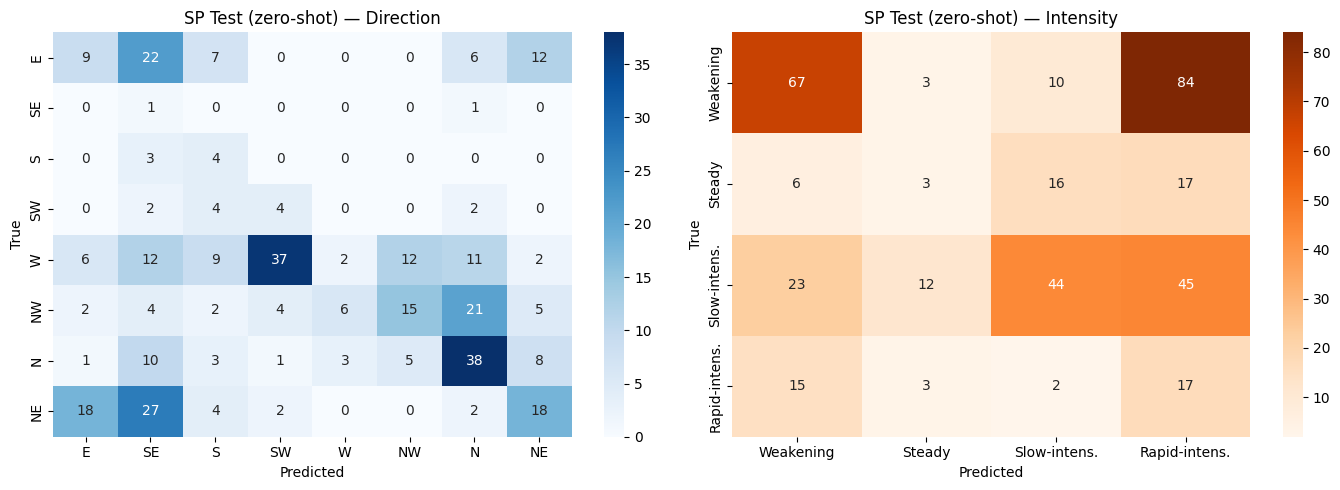

In [20]:
fig = plot_confusion_matrices(sp_zs_metrics, "SP Test (zero-shot)")
fig.savefig(PROJECT_ROOT / "figures" / "fno_sp_zeroshot_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [21]:
# ── Transfer gap analysis ──
print("\n" + "=" * 65)
print(" Transfer Gap: WP Val vs SP Zero-Shot")
print("=" * 65)
print(f"{'Metric':<20s} {'WP Val':>10s} {'SP Zero-Shot':>12s} {'Gap':>10s}")
print("-" * 55)
for metric, label in [("dir_acc", "Dir Accuracy"),
                       ("dir_f1",  "Dir F1 (macro)"),
                       ("int_acc", "Int Accuracy"),
                       ("int_f1",  "Int F1 (macro)")]:
    wp = wp_val_metrics[metric]
    sp = sp_zs_metrics[metric]
    gap = sp - wp
    print(f"{label:<20s} {wp:>10.3f} {sp:>12.3f} {gap:>+10.3f}")


 Transfer Gap: WP Val vs SP Zero-Shot
Metric                   WP Val SP Zero-Shot        Gap
-------------------------------------------------------
Dir Accuracy              0.503        0.248     -0.255
Dir F1 (macro)            0.364        0.217     -0.147
Int Accuracy              0.558        0.357     -0.201
Int F1 (macro)            0.410        0.300     -0.109


## Section 6: Fine-Tuning on SP

We fine-tune the WP-trained model on the small SP training set (11 storms, ~400 timesteps). Two strategies are compared:
1. **Full fine-tune** — all parameters are trainable at a reduced learning rate
2. **Head-only** — freeze the FNO backbone, only train the classification heads

The expectation is that full fine-tuning will perform better given sufficient regularisation (early stopping, weight decay), while head-only is more robust to overfitting on the very small SP dataset.

In [22]:
def finetune(model_state, loaders_ft_train, loaders_ft_val,
             freeze_backbone=False, lr=FT_LR, epochs=FT_EPOCHS,
             patience=FT_PATIENCE):
    """Fine-tune a model from a saved state dict."""
    ft_model = FNO2dClassifier(
        in_channels=IN_CHANNELS, hidden_channels=HIDDEN_CHANNELS,
        n_modes=N_MODES, n_layers=N_LAYERS,
        n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
        env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
        dropout=BEST_DROPOUT,
    ).to(DEVICE)
    # Match head architecture
    aux_dim = 40 + 4
    head_in = HIDDEN_CHANNELS + aux_dim
    ft_model.head_dir = nn.Sequential(
        nn.Linear(head_in, BEST_HEAD_DIM), nn.GELU(),
        nn.Dropout(BEST_DROPOUT * 2),
        nn.Linear(BEST_HEAD_DIM, BEST_HEAD_DIM // 2), nn.GELU(),
        nn.Dropout(BEST_DROPOUT),
        nn.Linear(BEST_HEAD_DIM // 2, N_DIR_CLASSES),
    ).to(DEVICE)
    ft_model.head_int = nn.Sequential(
        nn.Linear(head_in, BEST_HEAD_DIM), nn.GELU(),
        nn.Dropout(BEST_DROPOUT * 2),
        nn.Linear(BEST_HEAD_DIM, BEST_HEAD_DIM // 2), nn.GELU(),
        nn.Dropout(BEST_DROPOUT),
        nn.Linear(BEST_HEAD_DIM // 2, N_INT_CLASSES),
    ).to(DEVICE)
    ft_model.load_state_dict(model_state)

    if freeze_backbone:
        for name, p in ft_model.named_parameters():
            if "head" not in name:
                p.requires_grad = False
        trainable = [p for p in ft_model.parameters() if p.requires_grad]
        print(f"Head-only: {sum(p.numel() for p in trainable):,} trainable params")
    else:
        trainable = ft_model.parameters()
        print("Full fine-tune: all params trainable")

    ft_optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=WEIGHT_DECAY)
    ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        ft_optimizer, T_max=epochs, eta_min=1e-6)

    best_loss = float("inf")
    best_state = None
    wait = 0
    ft_history = {"train_loss": [], "val_loss": [],
                  "val_dir_acc": [], "val_int_acc": []}

    for epoch in range(1, epochs + 1):
        t_loss, _, _ = train_one_epoch(ft_model, loaders_ft_train,
                                        ft_optimizer, DEVICE)
        v = evaluate(ft_model, loaders_ft_val, DEVICE)
        ft_scheduler.step()

        ft_history["train_loss"].append(t_loss)
        ft_history["val_loss"].append(v["loss"])
        ft_history["val_dir_acc"].append(v["dir_acc"])
        ft_history["val_int_acc"].append(v["int_acc"])

        if v["loss"] < best_loss:
            best_loss = v["loss"]
            best_state = deepcopy(ft_model.state_dict())
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  FT Epoch {epoch:3d} │ train_loss={t_loss:.4f} "
                  f"val_loss={v['loss']:.4f} dir={v['dir_acc']:.3f} "
                  f"int={v['int_acc']:.3f}")

        if wait >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    ft_model.load_state_dict(best_state)
    return ft_model, ft_history

In [23]:
# ── Strategy 1: Full fine-tune ──
print("Strategy 1: Full Fine-Tuning")
print("-" * 40)
ft_full_model, ft_full_hist = finetune(
    best_model_state, loaders["sp_ft_train"], loaders["sp_ft_val"],
    freeze_backbone=False
)
ft_full_metrics = evaluate(ft_full_model, loaders["sp_ft_val"], DEVICE)
print_metrics(ft_full_metrics, "SP Fine-Tuned (full) — Val")

Strategy 1: Full Fine-Tuning
----------------------------------------
Full fine-tune: all params trainable
  FT Epoch   1 │ train_loss=1.7598 val_loss=2.1703 dir=0.358 int=0.481
  FT Epoch  10 │ train_loss=1.2949 val_loss=2.1912 dir=0.333 int=0.370
  FT Epoch  20 │ train_loss=1.2602 val_loss=2.2038 dir=0.444 int=0.235
  Early stopping at epoch 22

 SP Fine-Tuned (full) — Val
  Direction — Acc: 0.358  F1 (macro): 0.217
  Intensity — Acc: 0.333  F1 (macro): 0.274


In [24]:
# ── Strategy 2: Head-only fine-tune ──
print("Strategy 2: Head-Only Fine-Tuning")
print("-" * 40)
ft_head_model, ft_head_hist = finetune(
    best_model_state, loaders["sp_ft_train"], loaders["sp_ft_val"],
    freeze_backbone=True
)
ft_head_metrics = evaluate(ft_head_model, loaders["sp_ft_val"], DEVICE)
print_metrics(ft_head_metrics, "SP Fine-Tuned (head-only) — Val")

Strategy 2: Head-Only Fine-Tuning
----------------------------------------
Head-only: 20,556 trainable params
  FT Epoch   1 │ train_loss=1.7690 val_loss=2.2339 dir=0.346 int=0.481
  FT Epoch  10 │ train_loss=1.4659 val_loss=2.2623 dir=0.321 int=0.370
  FT Epoch  20 │ train_loss=1.4822 val_loss=2.0887 dir=0.358 int=0.284


  FT Epoch  30 │ train_loss=1.3716 val_loss=2.0745 dir=0.346 int=0.272
  FT Epoch  40 │ train_loss=1.3778 val_loss=2.0568 dir=0.346 int=0.272

 SP Fine-Tuned (head-only) — Val
  Direction — Acc: 0.346  F1 (macro): 0.225
  Intensity — Acc: 0.272  F1 (macro): 0.216


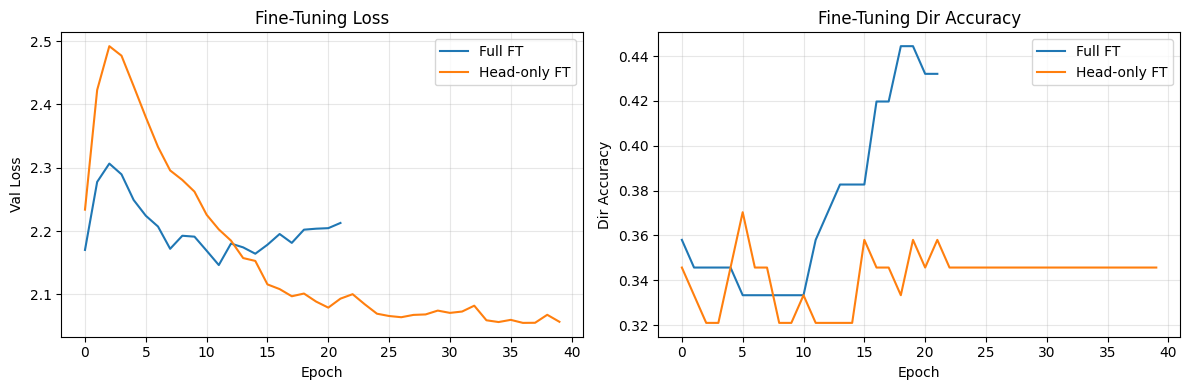

In [25]:
# ── Fine-tuning learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, label in [(ft_full_hist, "Full FT"), (ft_head_hist, "Head-only FT")]:
    axes[0].plot(hist["val_loss"], label=label)
    axes[1].plot(hist["val_dir_acc"], label=label)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss")
axes[0].set_title("Fine-Tuning Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dir Accuracy")
axes[1].set_title("Fine-Tuning Dir Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fno_finetune_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [26]:
# ── Evaluate best fine-tuned model on sp_test as well ──
# Pick whichever strategy performed better on sp_ft_val
if ft_full_metrics["dir_acc"] >= ft_head_metrics["dir_acc"]:
    best_ft_model = ft_full_model
    best_ft_strategy = "full"
else:
    best_ft_model = ft_head_model
    best_ft_strategy = "head-only"

print(f"Best fine-tuning strategy: {best_ft_strategy}")
sp_ft_test_metrics = evaluate(best_ft_model, loaders["sp_test"], DEVICE)
print_metrics(sp_ft_test_metrics, f"SP Test (fine-tuned, {best_ft_strategy})")

Best fine-tuning strategy: full

 SP Test (fine-tuned, full)
  Direction — Acc: 0.346  F1 (macro): 0.272
  Intensity — Acc: 0.335  F1 (macro): 0.288


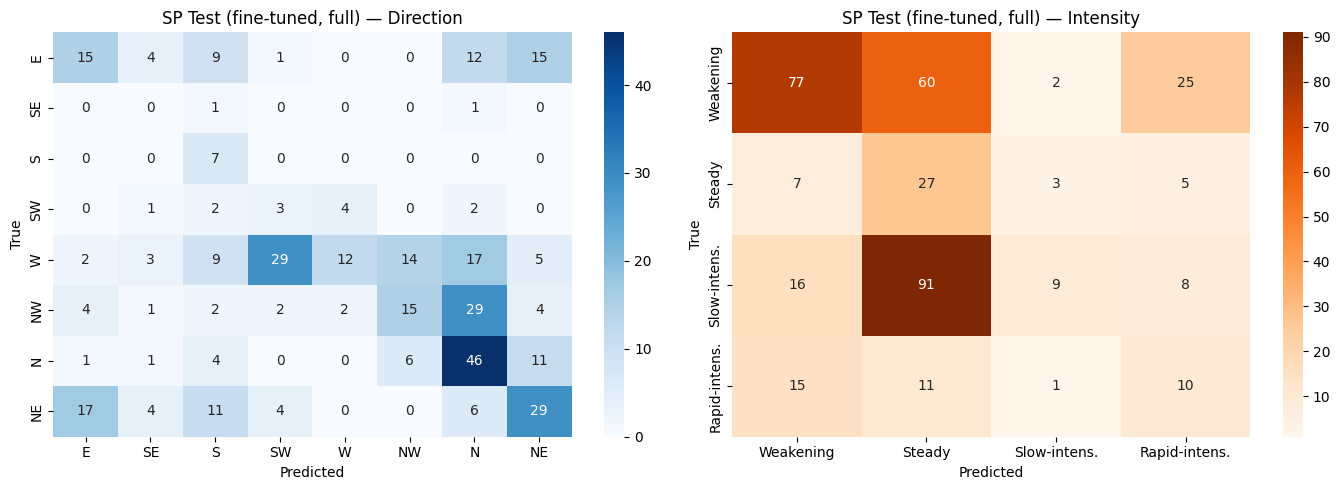

In [27]:
fig = plot_confusion_matrices(sp_ft_test_metrics,
                              f"SP Test (fine-tuned, {best_ft_strategy})")
fig.savefig(PROJECT_ROOT / "figures" / "fno_sp_finetuned_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [28]:
# ── Three-way comparison ──
print("\n" + "=" * 75)
print(" Cross-Basin Transfer Summary")
print("=" * 75)
print(f"{'Setting':<30s} {'Dir Acc':>8s} {'Dir F1':>8s} "
      f"{'Int Acc':>8s} {'Int F1':>8s}")
print("-" * 65)

for name, m in [
    ("WP Val (in-basin)",          wp_val_metrics),
    ("SP Test (zero-shot)",        sp_zs_metrics),
    (f"SP Test (FT {best_ft_strategy})", sp_ft_test_metrics),
]:
    print(f"{name:<30s} {m['dir_acc']:>8.3f} {m['dir_f1']:>8.3f} "
          f"{m['int_acc']:>8.3f} {m['int_f1']:>8.3f}")


 Cross-Basin Transfer Summary
Setting                         Dir Acc   Dir F1  Int Acc   Int F1
-----------------------------------------------------------------
WP Val (in-basin)                 0.503    0.364    0.558    0.410
SP Test (zero-shot)               0.248    0.217    0.357    0.300
SP Test (FT full)                 0.346    0.272    0.335    0.288


## Section 7: Analysis & Fourier Mode Importance

A unique advantage of the FNO architecture is that we can directly inspect **which Fourier modes** the model has learned to rely on. Each spectral layer has complex-valued weights indexed by mode number — the magnitude of these weights indicates how important each spatial frequency is for the prediction task.

Low-frequency modes correspond to large-scale atmospheric patterns (e.g., SST gradients, overall cyclone structure), while higher modes capture finer-scale features (e.g., eyewall convection, wind shear boundaries).

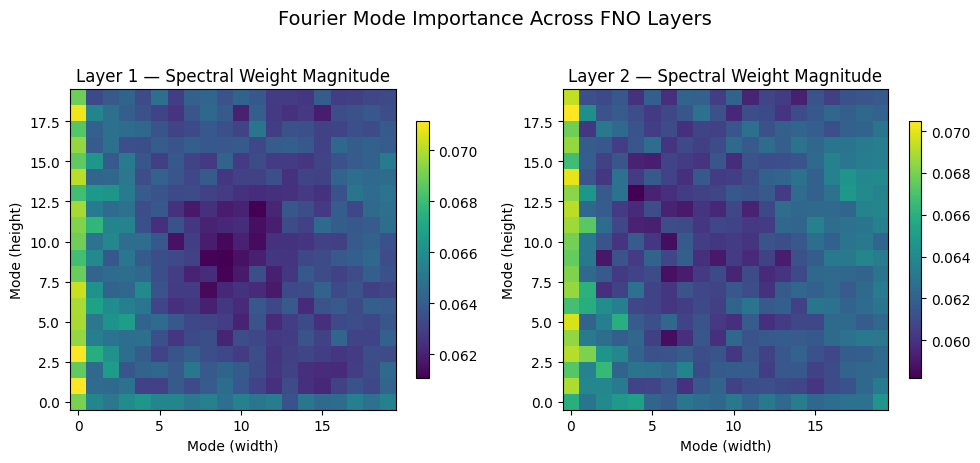

In [29]:
# ── Fourier mode importance per layer ──
n_layers_actual = len(model.spectral_layers)
n_cols = min(n_layers_actual, 3)
n_rows = (n_layers_actual + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows),
                          squeeze=False)

for i, ax in enumerate(axes.flat):
    if i >= n_layers_actual:
        ax.axis("off")
        continue

    w1 = model.spectral_layers[i].weights1.detach().cpu()
    w2 = model.spectral_layers[i].weights2.detach().cpu()
    mag = (w1.abs().mean(dim=(0, 1)) + w2.abs().mean(dim=(0, 1))) / 2

    im = ax.imshow(mag.numpy(), cmap="viridis", aspect="auto",
                   origin="lower")
    ax.set_xlabel("Mode (width)"); ax.set_ylabel("Mode (height)")
    ax.set_title(f"Layer {i+1} — Spectral Weight Magnitude")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Fourier Mode Importance Across FNO Layers", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fno_mode_importance.png", dpi=150,
            bbox_inches="tight")
plt.show()

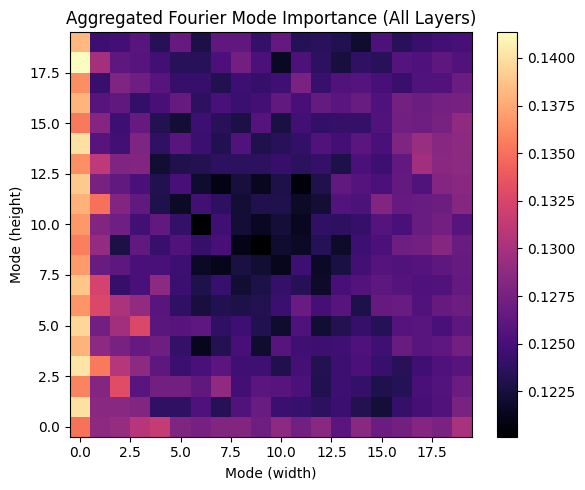

Top-5 most important mode pairs (height, width):
  mode (18,  0) — magnitude: 0.1413
  mode ( 3,  0) — magnitude: 0.1402
  mode (14,  0) — magnitude: 0.1401
  mode ( 1,  0) — magnitude: 0.1401
  mode ( 5,  0) — magnitude: 0.1395


In [30]:
# ── Aggregated mode importance (sum across all layers) ──
n_layers_actual = len(model.spectral_layers)
modes_h = model.spectral_layers[0].modes1
modes_w = model.spectral_layers[0].modes2

total_mag = torch.zeros(modes_h, modes_w)
for i in range(n_layers_actual):
    w1 = model.spectral_layers[i].weights1.detach().cpu()
    w2 = model.spectral_layers[i].weights2.detach().cpu()
    total_mag += (w1.abs().mean(dim=(0, 1)) + w2.abs().mean(dim=(0, 1))) / 2

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(total_mag.numpy(), cmap="magma", aspect="auto", origin="lower")
ax.set_xlabel("Mode (width)"); ax.set_ylabel("Mode (height)")
ax.set_title("Aggregated Fourier Mode Importance (All Layers)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fno_mode_importance_agg.png", dpi=150,
            bbox_inches="tight")
plt.show()

print("Top-5 most important mode pairs (height, width):")
flat = total_mag.flatten()
top5_idx = flat.argsort(descending=True)[:5]
for idx in top5_idx:
    r, c = divmod(idx.item(), modes_w)
    print(f"  mode ({r:2d}, {c:2d}) — magnitude: {flat[idx]:.4f}")

Storm: OMA (43 timesteps)


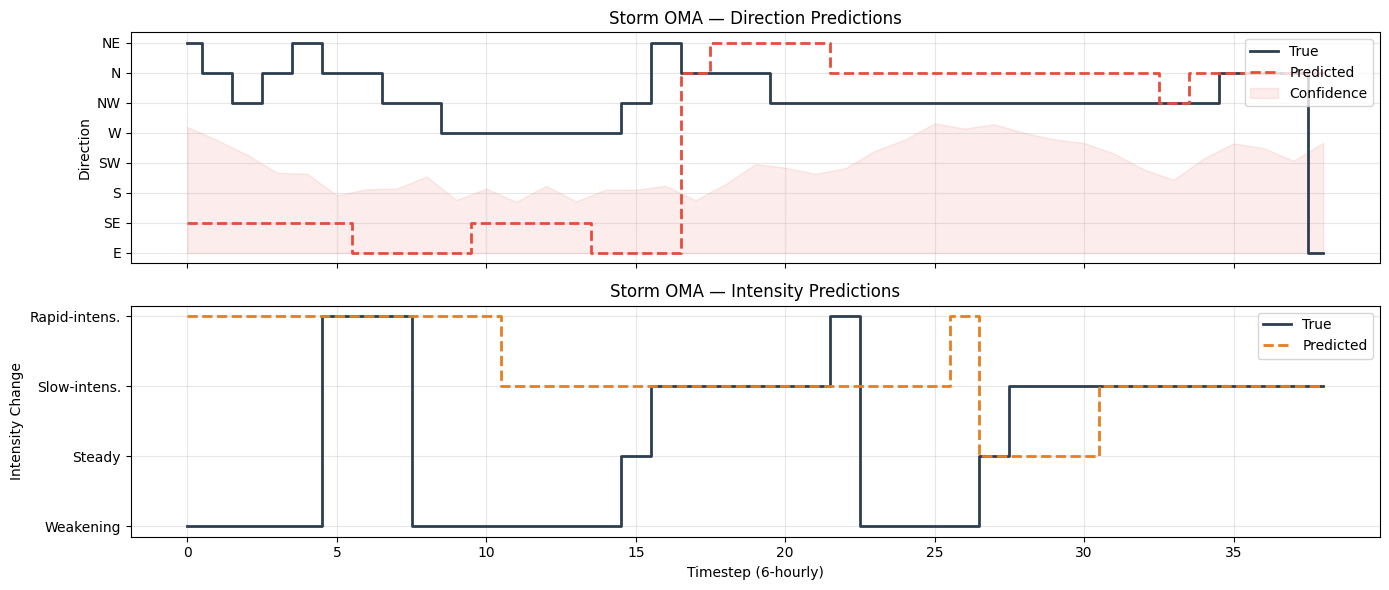

In [31]:
# ── Per-storm prediction timeline (sample SP storm) ──
# Pick one storm from sp_test and show predictions over time
sp_grids  = raw["sp_test"]["grids"]
sp_env    = raw["sp_test"]["env"]
sp_d1d    = raw["sp_test"]["data1d"]
sp_labels = raw["sp_test"]["labels"]

# Pick the longest storm
storm_id = max(sp_grids, key=lambda k: sp_grids[k].shape[0])
n_ts = sp_grids[storm_id].shape[0]
print(f"Storm: {storm_id} ({n_ts} timesteps)")

# Run predictions for each timestep
model.eval()
dir_preds, int_preds = [], []
dir_confs, int_confs = [], []
dir_true_list, int_true_list = [], []

with torch.no_grad():
    for t in range(n_ts):
        d_lbl = sp_labels[storm_id]["direction_reflected"][t].item()
        i_lbl = sp_labels[storm_id]["intensity"][t].item()
        if d_lbl == -1 or i_lbl == -1:
            continue

        # Grids are already normalised by preprocessing
        g = sp_grids[storm_id][t].unsqueeze(0).to(DEVICE)
        e = sp_env[storm_id][t].unsqueeze(0).to(DEVICE)
        d = sp_d1d[storm_id][t].unsqueeze(0).to(DEVICE)

        d_logits, i_logits = model(g, e, d)
        d_probs = F.softmax(d_logits, dim=1)
        i_probs = F.softmax(i_logits, dim=1)

        dir_preds.append(d_logits.argmax(1).item())
        int_preds.append(i_logits.argmax(1).item())
        dir_confs.append(d_probs.max().item())
        int_confs.append(i_probs.max().item())
        dir_true_list.append(d_lbl)
        int_true_list.append(i_lbl)

timesteps = np.arange(len(dir_preds))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Direction
axes[0].step(timesteps, dir_true_list, where="mid", label="True",
             color="#2c3e50", linewidth=2)
axes[0].step(timesteps, dir_preds, where="mid", label="Predicted",
             color="#e74c3c", linewidth=2, linestyle="--")
axes[0].fill_between(timesteps, 0, [c * 7 for c in dir_confs],
                     alpha=0.1, color="#e74c3c", label="Confidence")
axes[0].set_yticks(range(8))
axes[0].set_yticklabels(DIR_LABELS)
axes[0].set_ylabel("Direction")
axes[0].set_title(f"Storm {storm_id} — Direction Predictions")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Intensity
axes[1].step(timesteps, int_true_list, where="mid", label="True",
             color="#2c3e50", linewidth=2)
axes[1].step(timesteps, int_preds, where="mid", label="Predicted",
             color="#e67e22", linewidth=2, linestyle="--")
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(INTE_LABELS)
axes[1].set_xlabel("Timestep (6-hourly)")
axes[1].set_ylabel("Intensity Change")
axes[1].set_title(f"Storm {storm_id} — Intensity Predictions")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fno_storm_timeline.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [32]:
# ── Final summary ──
print("\n" + "=" * 80)
print(" FNO Cross-Basin Transfer — Final Results")
print("=" * 80)
print(f"\nModel: FNO2dClassifier")
print(f"  Spectral layers: {N_LAYERS}, Fourier modes: {N_MODES}, "
      f"Hidden channels: {HIDDEN_CHANNELS}")
print(f"  Parameters: {n_params:,}")
print(f"  Multimodal: grid (15ch) + env ({40 if USE_ENV else 0}d) "
      f"+ 1D ({4 if USE_1D else 0}d)")
print(f"  Optimizer: {OPTIMIZER.upper()}, LR: {LR}")

print(f"\n{'Setting':<35s} {'Dir Acc':>8s} {'Dir F1':>8s} "
      f"{'Int Acc':>8s} {'Int F1':>8s}")
print("-" * 70)
for name, m in [
    ("WP Validation (in-basin)",          wp_val_metrics),
    ("SP Test (zero-shot)",               sp_zs_metrics),
    (f"SP Test (fine-tuned, {best_ft_strategy})", sp_ft_test_metrics),
]:
    print(f"{name:<35s} {m['dir_acc']:>8.3f} {m['dir_f1']:>8.3f} "
          f"{m['int_acc']:>8.3f} {m['int_f1']:>8.3f}")

# Transfer efficiency
zs_gap_dir = sp_zs_metrics["dir_acc"] - wp_val_metrics["dir_acc"]
ft_recovery = (sp_ft_test_metrics["dir_acc"] - sp_zs_metrics["dir_acc"])
print(f"\nZero-shot transfer gap (direction):  {zs_gap_dir:+.3f}")
print(f"Fine-tuning recovery (direction):     {ft_recovery:+.3f}")

# Save model
save_path = PROJECT_ROOT / "checkpoints" / "fno_best_wp.pt"
torch.save(best_model_state, save_path)
print(f"\nBest WP model saved to: {save_path}")

ft_save_path = PROJECT_ROOT / "checkpoints" / "fno_best_ft.pt"
torch.save(best_ft_model.state_dict(), ft_save_path)
print(f"Best fine-tuned model saved to: {ft_save_path}")


 FNO Cross-Basin Transfer — Final Results

Model: FNO2dClassifier
  Spectral layers: 2, Fourier modes: 20, Hidden channels: 80
  Parameters: 10,281,596
  Multimodal: grid (15ch) + env (40d) + 1D (4d)
  Optimizer: MUON, LR: 0.0007831506014327231

Setting                              Dir Acc   Dir F1  Int Acc   Int F1
----------------------------------------------------------------------
WP Validation (in-basin)               0.503    0.364    0.558    0.410
SP Test (zero-shot)                    0.248    0.217    0.357    0.300
SP Test (fine-tuned, full)             0.346    0.272    0.335    0.288

Zero-shot transfer gap (direction):  -0.255
Fine-tuning recovery (direction):     +0.098

Best WP model saved to: /root/climate-change-group-project/experiments/fno_best_wp.pt
Best fine-tuned model saved to: /root/climate-change-group-project/experiments/fno_best_ft.pt
